# Banking Fraud Detection — Final Evaluation

This notebook performs the final evaluation of the selected fraud detection approach using a validation period for threshold selection and an untouched temporal test set for final evaluation.

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv("../data/train_temporal.csv")
test_df = pd.read_csv("../data/test_temporal.csv")

print("Training data:", train_df.shape)
print("Testing data:", test_df.shape)

Training data: (8000, 10)
Testing data: (2000, 10)


In [3]:
split_index = int(len(train_df) * 0.80)

train_part = train_df.iloc[:split_index].copy()
validation_df = train_df.iloc[split_index:].copy()

print("Training portion:", train_part.shape)
print("Validation portion:", validation_df.shape)

Training portion: (6400, 10)
Validation portion: (1600, 10)


In [4]:
target = "is_fraud"

for d in [train_part, validation_df, test_df]:
    d["timestamp"] = pd.to_datetime(d["timestamp"])
    d["hour_of_day"] = d["timestamp"].dt.hour
    d["day_of_week"] = d["timestamp"].dt.dayofweek

drop_columns = [
    "is_fraud",
    "transaction_id",
    "customer_id",
    "timestamp"
]

X_train = train_part.drop(columns=drop_columns)
y_train = train_part[target]

X_validation = validation_df.drop(columns=drop_columns)
y_validation = validation_df[target]

X_test = test_df.drop(columns=drop_columns)
y_test = test_df[target]

In [5]:
categorical_features = [
    "merchant_category",
    "customer_location",
    "device_type"
]

numerical_features = [
    "amount",
    "customer_age",
    "previous_transactions",
    "hour_of_day",
    "day_of_week"
]

In [6]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(
    X_train[categorical_features]
)

X_validation_cat = encoder.transform(
    X_validation[categorical_features]
)

X_test_cat = encoder.transform(
    X_test[categorical_features]
)

scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    X_train[numerical_features]
)

X_validation_num = scaler.transform(
    X_validation[numerical_features]
)

X_test_num = scaler.transform(
    X_test[numerical_features]
)

In [8]:
X_train_final = np.hstack([
    X_train_num,
    X_train_cat
])

X_validation_final = np.hstack([
    X_validation_num,
    X_validation_cat
])

X_test_final = np.hstack([
    X_test_num,
    X_test_cat
])

In [9]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_final,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
is_fraud
0    6282
1     118
Name: count, dtype: int64

After SMOTE:
is_fraud
0    6282
1    6282
Name: count, dtype: int64


d:\Application\Python\Python\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\Application\Python\Python\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "d:\Application\Python\Python\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Application\Python\Python\Lib\subprocess.py", line 1036, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^

In [11]:
final_model = LogisticRegression(
    max_iter=1000
)

final_model.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000)

In [12]:
y_validation_prob = final_model.predict_proba(
    X_validation_final
)[:, 1]

In [13]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

threshold_results = []

for threshold in thresholds:

    y_validation_pred = (
        y_validation_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_validation,
            y_validation_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_validation,
            y_validation_pred,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_validation,
            y_validation_pred,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1-Score
0,0.1,0.016281,1.000000,0.032039
1,0.2,0.015934,0.961538,0.031348
2,0.3,0.017042,0.961538,0.033490
3,0.4,0.017399,0.807692,0.034063
4,0.5,0.017995,0.538462,0.034826


In [14]:
best_threshold = threshold_df.loc[
    threshold_df["F1-Score"].idxmax(),
    "Threshold"
]

print("Selected threshold:", best_threshold)

Selected threshold: 0.5


In [15]:
y_test_prob = final_model.predict_proba(
    X_test_final
)[:, 1]

y_test_pred = (
    y_test_prob >= best_threshold
).astype(int)

In [16]:
final_results = {
    "Model": "Logistic Regression - SMOTE",
    "Threshold": best_threshold,
    "Precision": precision_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),
    "F1-Score": f1_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),
    "PR-AUC": average_precision_score(
        y_test,
        y_test_prob
    )
}

final_results

{'Model': 'Logistic Regression - SMOTE',
 'Threshold': np.float64(0.5),
 'Precision': np.float64(0.021551724137931036),
 'Recall': np.float64(0.45454545454545453),
 'F1-Score': np.float64(0.0411522633744856),
 'PR-AUC': np.float64(0.021334530531960806)}

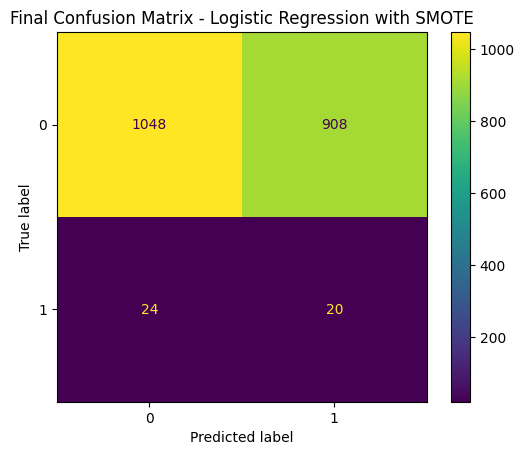

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred
)

plt.title(
    "Final Confusion Matrix - Logistic Regression with SMOTE"
)

plt.show()

### Final Observations

- Logistic Regression with SMOTE was selected as the final candidate based on the model comparison.
- The classification threshold was selected using the validation period from the training data.
- The validation process selected a threshold of 0.5 based on the highest F1-Score.
- On the final temporal test set, the model achieved a recall of 0.4545, detecting 20 out of 44 fraudulent transactions.
- The model achieved a precision of 0.0216, indicating a high number of false positives.
- The final F1-Score was 0.0412 and the PR-AUC was 0.0213.
- The results show that the model can identify a portion of fraudulent transactions, but the high number of false positives limits its practical effectiveness.
- The final test set was not used for threshold selection.